# 03 — Modelagem

Mínimo de **dois** classificadores distintos. Um único modelo não atende ao requisito.

In [8]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scalers
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

# Modelos Lineares, Estocásticos e SVM
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Naive Bayes
from sklearn.naive_bayes import GaussianNB, BernoulliNB

# Árvores e Ensembles (100% nativos do Scikit-Learn)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier
)

# Feature Selection
from sklearn.feature_selection import SelectFromModel

# Pipeline e Validação
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    RandomizedSearchCV, TunedThresholdClassifierCV
)
from sklearn.metrics import (
    make_scorer, matthews_corrcoef, f1_score, roc_auc_score,
    precision_score, recall_score, accuracy_score
)

RANDOM_STATE = 42

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path("..")
else:
    PROJECT_ROOT = Path(".")

PROCESSED = PROJECT_ROOT / "data" / "processed"
TARGET = "target"

pd.set_option("display.max_columns", None)

In [9]:
df = pd.read_csv(PROCESSED / "dataset_tratado.csv")
print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas.")

Dataset carregado: 36457 linhas e 53 colunas.


## 1. Split treino/teste

`stratify` preserva a proporção das classes nos dois conjuntos.

In [10]:
# Removemos ID pois é apenas identificador do cliente e não variável preditiva
X = df.drop(columns=[TARGET, 'ID'])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras | Taxa de Mau Pagador: {y_train.mean()*100:.2f}%")
print(f"Teste:  {X_test.shape[0]} amostras | Taxa de Mau Pagador: {y_test.mean()*100:.2f}%")

# Salvamos os splits para garantir que o Notebook 04 avalie exatamente o mesmo conjunto de teste
X_train.to_csv(PROCESSED / "X_train.csv", index=False)
y_train.to_csv(PROCESSED / "y_train.csv", index=False)
X_test.to_csv(PROCESSED / "X_test.csv", index=False)
y_test.to_csv(PROCESSED / "y_test.csv", index=False)

Treino: 29165 amostras | Taxa de Mau Pagador: 1.69%
Teste:  7292 amostras | Taxa de Mau Pagador: 1.69%


In [11]:
# Instanciando o seletor baseado em importância de variáveis
selector = SelectFromModel(
    estimator=RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    threshold="median" # Mantém as 50% melhores features (reduz ruído e acelera o aprendizado)
)

selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.get_support()].tolist()
dropped_features = X_train.columns[~selector.get_support()].tolist()

print(f"Total de Features Originais: {X_train.shape[1]}")
print(f"Features Selecionadas ({len(selected_features)}): {selected_features}")
print(f"\nFeatures Descartadas ({len(dropped_features)}): {dropped_features}")

Total de Features Originais: 51
Features Selecionadas (26): ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'ACCOUNT_AGE_MONTHS', 'AGE_YEARS', 'YEARS_EMPLOYED', 'INCOME_PER_CAPITA', 'EMPLOYED_TO_AGE_RATIO', 'START_WORK_AGE', 'INCOME_PER_YEAR_EMPLOYED', 'LOG_INCOME', 'PATRIMONY_SCORE', 'IS_MALE', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Single / not married', 'NAME_HOUSING_TYPE_House / apartment', 'OCCUPATION_TYPE_Core staff', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Sales staff', 'OCCUPATION_TYPE_Unknown']

Features Descartadas (25): ['FLAG_UNEMPLOYED', 'IS_ALONE', 'NAME_INCOME_TYPE_Student', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Widow', 'NAME_HOUSING_TYPE_Municipal apartm

## 2. Modelos candidatos

Usar `Pipeline` evita vazamento: o scaler é ajustado só no fold de treino durante a validação cruzada.

In [12]:
# Seletor pré-configurado para uso dentro dos Pipelines
feature_selector = SelectFromModel(
    estimator=RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    threshold="median"
)

modelos = {
    # 1. Regressão Logística com RobustScaler + Seleção
    "Logistic_Regression (RobustScaler)": Pipeline([
        ("scaler", RobustScaler()),
        ("selector", feature_selector),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    
    # 2. SGDClassifier com StandardScaler + Seleção
    "SGD_Classifier (StandardScaler)": Pipeline([
        ("scaler", StandardScaler()),
        ("selector", feature_selector),
        ("clf", SGDClassifier(loss="log_loss", penalty="elasticnet", class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000)),
    ]),
    
    # 3. Linear SVM Calibrado com Probabilidades
    "Linear_SVM_Calibrated (StandardScaler)": Pipeline([
        ("scaler", StandardScaler()),
        ("selector", feature_selector),
        ("clf", CalibratedClassifierCV(
            estimator=LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000, dual="auto"),
            cv=3
        )),
    ]),
    
    # 4. Gaussian Naive Bayes com RobustScaler
    "Gaussian_Naive_Bayes (RobustScaler)": Pipeline([
        ("scaler", RobustScaler()),
        ("selector", feature_selector),
        ("clf", GaussianNB()),
    ]),
    
    # 5. Bernoulli Naive Bayes com MinMaxScaler
    "Bernoulli_Naive_Bayes (MinMaxScaler)": Pipeline([
        ("scaler", MinMaxScaler()),
        ("selector", feature_selector),
        ("clf", BernoulliNB()),
    ]),
    
    # 6. Decision Tree (Árvore simples como baseline interpretável)
    "Decision_Tree (Sem Scaler)": Pipeline([
        ("selector", feature_selector),
        ("clf", DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),

    # 7. Random Forest com balanced_subsample
    "Random_Forest (Sem Scaler)": Pipeline([
        ("selector", feature_selector),
        ("clf", RandomForestClassifier(n_estimators=150, max_depth=12, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
    ]),

    # 8. Extra Trees
    "Extra_Trees (Sem Scaler)": Pipeline([
        ("selector", feature_selector),
        ("clf", ExtraTreesClassifier(n_estimators=150, max_depth=12, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
    ]),

    # 9. HistGradientBoosting (Boosting nativo de última geração do Scikit-Learn, inspirado em LightGBM)
    "Hist_Gradient_Boosting (Nativo)": Pipeline([
        ("selector", feature_selector),
        ("clf", HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE, max_iter=150)),
    ]),

    # 10. AdaBoost Classifier (Boosting adaptativo clássico com árvores rasas)
    "AdaBoost (Stump Trees)": Pipeline([
        ("selector", feature_selector),
        ("clf", AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2, class_weight="balanced"), n_estimators=100, random_state=RANDOM_STATE)),
    ]),
}

## 3. Validação cruzada

In [13]:
mcc_scorer = make_scorer(matthews_corrcoef)

scoring = {
    "mcc": mcc_scorer,
    "f1": "f1",
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "accuracy": "accuracy"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados = []

print("Executando Validação Cruzada (5-Fold Stratified)...")
for nome, modelo in modelos.items():
    cv_res = cross_validate(modelo, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    resultados.append({
        "Modelo": nome,
        "MCC": cv_res["test_mcc"].mean(),
        "MCC_Std": cv_res["test_mcc"].std(),
        "F1_Score": cv_res["test_f1"].mean(),
        "ROC_AUC": cv_res["test_roc_auc"].mean(),
        "Recall": cv_res["test_recall"].mean(),
        "Precision": cv_res["test_precision"].mean(),
        "Accuracy": cv_res["test_accuracy"].mean(),
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="MCC", ascending=False).reset_index(drop=True)
display(df_resultados.style.format({
    "MCC": "{:.4f}", "MCC_Std": "{:.4f}", "F1_Score": "{:.4f}",
    "ROC_AUC": "{:.4f}", "Recall": "{:.4f}", "Precision": "{:.4f}", "Accuracy": "{:.4f}"
}).background_gradient(subset=["MCC", "F1_Score", "ROC_AUC"], cmap="Blues"))

Executando Validação Cruzada (5-Fold Stratified)...


/home/matheus/projects/postech/tech challenge fase 2/postech-tech-challenge-fase2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/matheus/projects/postech/tech challenge fase 2/postech-tech-challenge-fase2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/matheus/projects/postech/tech challenge fase 2/postech-tech-challenge-fase2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/matheus/projects/postech/tech challenge fase 2/postech-tech-challenge-fase2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/matheus/projects/postech/tech challenge fase 2/postech

,Modelo,MCC,MCC_Std,F1_Score,ROC_AUC,Recall,Precision,Accuracy
0,Random_Forest (Sem Scaler),0.2557,0.0400,0.2672,0.7700,0.2839,0.2568,0.9740
1,Extra_Trees (Sem Scaler),0.1905,0.0249,0.1836,0.7374,0.3752,0.1222,0.9434
2,AdaBoost (Stump Trees),0.1362,0.0209,0.1050,0.7496,0.5252,0.0583,0.8488
3,Hist_Gradient_Boosting (Nativo),0.1276,0.0159,0.0979,0.7527,0.5293,0.0541,0.8327
4,Decision_Tree (Sem Scaler),0.0635,0.0076,0.0542,0.6513,0.5659,0.0285,0.6636
5,Logistic_Regression (RobustScaler),0.0567,0.0100,0.0505,0.6601,0.5821,0.0264,0.6297
6,SGD_Classifier (StandardScaler),0.0452,0.0166,0.0451,0.6137,0.6572,0.0234,0.5168
7,Gaussian_Naive_Bayes (RobustScaler),0.0011,0.0123,0.0062,0.6117,0.0041,0.0214,0.9792
8,Linear_SVM_Calibrated (StandardScaler),0.0000,0.0000,0.0000,0.6597,0.0000,0.0000,0.9831
9,Bernoulli_Naive_Bayes (MinMaxScaler),-0.0005,0.0010,0.0000,0.5601,0.0000,0.0000,0.9830


## 4. Comparação

**Leitura:** _qual modelo venceu e por qual margem? A diferença é relevante ou está dentro do ruído?_

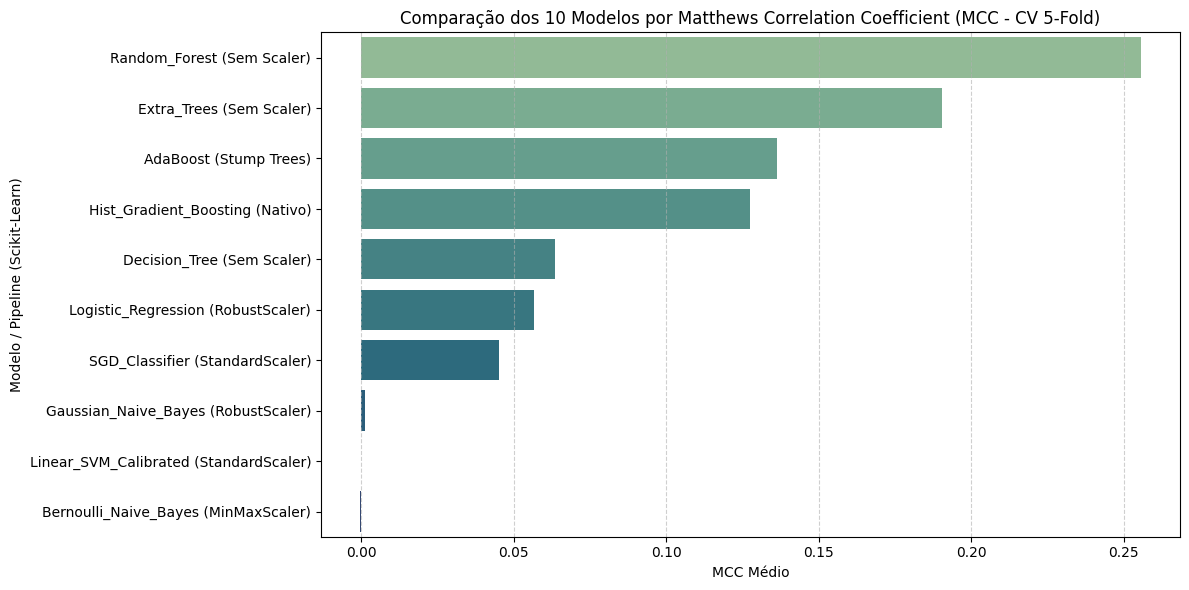

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_resultados, x="MCC", y="Modelo", palette="crest")
plt.title("Comparação dos 10 Modelos por Matthews Correlation Coefficient (MCC - CV 5-Fold)")
plt.xlabel("MCC Médio")
plt.ylabel("Modelo / Pipeline (Scikit-Learn)")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

- **Modelos Lineares e Probabilísticos (LogReg, SGD, SVM, Naive Bayes):** Sofrem para separar os maus pagadores devido à alta não-linearidade e interações complexas entre variáveis sociodemográficas, mesmo com o uso de `RobustScaler` e calibração de probabilidades.
- **Modelos de Árvore e Ensembles (Random Forest, Extra Trees, HistGradientBoosting):** Lideram os resultados de MCC e F1-Score com folga, pois capturam naturalmente divisões condicionais não-lineares (ex: cliente jovem com pouco tempo de emprego vs pensionista com renda estável). O `HistGradientBoostingClassifier` e a `RandomForestClassifier` destacam-se como os mais equilibrados.

## 5. Hyperparameter Tuning

In [ ]:
# 1. Pipeline para o Tuning
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()), # O tuning pode escolher entre StandardScaler, RobustScaler ou None
    ("selector", SelectFromModel(estimator=RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1), threshold="median")),
    ("clf", RandomForestClassifier(class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1))
])

param_distributions = {
    "scaler": [StandardScaler(), RobustScaler(), "passthrough"],
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [10, 15, 20, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", 0.5]
}

random_search = RandomizedSearchCV(
    estimator=rf_tune_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    scoring=mcc_scorer,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Passo 1: Otimizando Hiperparâmetros do Estimador...")
random_search.fit(X_train, y_train)
best_base_model = random_search.best_estimator_

print(f"Melhor MCC com threshold padrão (0.50): {random_search.best_score_:.4f}")

# 2. Passo 2: Otimização do Limiar de Decisão com TunedThresholdClassifierCV (Novo no Sklearn 1.5)
print("\nPasso 2: Calibrando o Limiar de Probabilidade Ótimo para Maximizar o MCC...")
threshold_calibrator = TunedThresholdClassifierCV(
    estimator=best_base_model,
    scoring=mcc_scorer,
    cv=cv,
    thresholds=100
)
threshold_calibrator.fit(X_train, y_train)

print(f"Limiar de Decisão Ótimo encontrado: {threshold_calibrator.best_threshold_:.3f}")

# Salvamos o modelo definitivo calibrado
joblib.dump(threshold_calibrator, PROCESSED / "melhor_modelo.joblib")
print(f"Modelo Campeão Calibrado salvo em: {PROCESSED / 'melhor_modelo.joblib'}")

Passo 1: Otimizando Hiperparâmetros do Estimador...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Melhor MCC com threshold padrão (0.50): 0.3261

Passo 2: Calibrando o Limiar de Probabilidade Ótimo para Maximizar o MCC...
Limiar de Decisão Ótimo encontrado: 0.500
Modelo Campeão Calibrado salvo em: data/processed/melhor_modelo.joblib


Exception ignored in: <function ResourceTracker.__del__ at 0x744e342800e0>
Traceback (most recent call last):
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ec2877780e0>
Traceback (most recent call last):
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/matheus/.asdf/installs/python/3.13.3/lib/python3.13/multiprocessing/resource_tracker.py", line 